In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)

### Data loading

In [2]:
# Paths
base_path = r"C:\Users\LOQ\Downloads\smart meter"

In [4]:
# 1️Daily energy data (main)
daily_df = pd.read_csv(f"{base_path}\\daily_dataset.csv", parse_dates=['day'])
print("daily_dataset.csv loaded:", daily_df.shape)

daily_dataset.csv loaded: (3510433, 9)


In [5]:
# 2️Household info (ACORN, tariff)
household_df = pd.read_csv(f"{base_path}\\informations_households.csv")
print("informations_households.csv loaded:", household_df.shape)

informations_households.csv loaded: (5566, 5)


In [16]:
# 3️ACORN socioeconomic details (for later interpretation only)
acorn_df = pd.read_csv(f"{base_path}\\acorn_details.csv", encoding='latin1')
print("acorn_details.csv loaded:", acorn_df.shape)

acorn_details.csv loaded: (826, 20)


In [7]:
# 4️Weather (daily)
weather_df = pd.read_csv(f"{base_path}\\weather_daily_darksky.csv")
print("weather_daily_darksky.csv loaded:", weather_df.shape)

weather_daily_darksky.csv loaded: (882, 32)


In [9]:
# Fix date column for weather (called 'time')
weather_df['time'] = pd.to_datetime(weather_df['time'], dayfirst=True, errors='coerce')

In [10]:
# UK bank holidays
holidays_df = pd.read_csv(f"{base_path}\\uk_bank_holidays.csv")
print("uk_bank_holidays.csv loaded:", holidays_df.shape)

uk_bank_holidays.csv loaded: (25, 2)


In [12]:
# Fix date column for holidays
holidays_df['Bank holidays'] = pd.to_datetime(holidays_df['Bank holidays'], dayfirst=True, errors='coerce')

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1994289211.py:2: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  holidays_df['Bank holidays'] = pd.to_datetime(holidays_df['Bank holidays'], dayfirst=True, errors='coerce')


### Merging Datasets & basic EDA

In [13]:
# Merge 1: Energy + Household Info
merged_df = daily_df.merge(household_df, on="LCLid", how="left")

# Merge 2: Add Weather Info (join on date)
merged_df = merged_df.merge(weather_df, left_on="day", right_on="time", how="left")

# Merge 3: Add Holiday Info
merged_df['is_holiday'] = merged_df['day'].isin(holidays_df['Bank holidays'])

In [17]:
merged_df.head(5)

,LCLid,day,energy_median,energy_mean,energy_max,energy_count,energy_std,energy_sum,energy_min,stdorToU,Acorn,Acorn_grouped,file,temperatureMax,temperatureMaxTime,windBearing,icon,dewPoint,temperatureMinTime,cloudCover,windSpeed,pressure,apparentTemperatureMinTime,apparentTemperatureHigh,precipType,visibility,humidity,apparentTemperatureHighTime,apparentTemperatureLow,apparentTemperatureMax,uvIndex,time,sunsetTime,temperatureLow,temperatureMin,temperatureHigh,sunriseTime,temperatureHighTime,uvIndexTime,summary,temperatureLowTime,apparentTemperatureMin,apparentTemperatureMaxTime,apparentTemperatureLowTime,moonPhase,is_holiday
0,MAC000131,2011-12-15,0.4850,0.432045,0.868,22,0.239146,9.505,0.072,Std,ACORN-E,Affluent,block_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,MAC000131,2011-12-16,0.1415,0.296167,1.116,48,0.281471,14.216,0.031,Std,ACORN-E,Affluent,block_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,MAC000131,2011-12-17,0.1015,0.189812,0.685,48,0.188405,9.111,0.064,Std,ACORN-E,Affluent,block_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,MAC000131,2011-12-18,0.1140,0.218979,0.676,48,0.202919,10.511,0.065,Std,ACORN-E,Affluent,block_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,MAC000131,2011-12-19,0.1910,0.325979,0.788,48,0.259205,15.647,0.066,Std,ACORN-E,Affluent,block_22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


In [18]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3510433 entries, 0 to 3510432
Data columns (total 46 columns):
 #   Column                       Dtype         
---  ------                       -----         
 0   LCLid                        object        
 1   day                          datetime64[ns]
 2   energy_median                float64       
 3   energy_mean                  float64       
 4   energy_max                   float64       
 5   energy_count                 int64         
 6   energy_std                   float64       
 7   energy_sum                   float64       
 8   energy_min                   float64       
 9   stdorToU                     object        
 10  Acorn                        object        
 11  Acorn_grouped                object        
 12  file                         object        
 13  temperatureMax               float64       
 14  temperatureMaxTime           object        
 15  windBearing                  float64       
 16  

In [21]:
# Missing value percentage
missing = merged_df.isna().mean().sort_values(ascending=False) * 100
print("\nMissing Values (%):\n", missing.head(15))


Missing Values (%):
 cloudCover                     84.512965
uvIndex                        84.512965
uvIndexTime                    84.512965
apparentTemperatureHighTime    84.367712
pressure                       84.367712
apparentTemperatureMinTime     84.367712
summary                        84.367712
precipType                     84.367712
visibility                     84.367712
humidity                       84.367712
apparentTemperatureMax         84.367712
apparentTemperatureLow         84.367712
time                           84.367712
sunsetTime                     84.367712
temperatureLow                 84.367712
dtype: float64


In [19]:
print("\nMissing Value Summary:")
print(merged_df.isna().sum().sort_values(ascending=False).head(15))


Missing Value Summary:
cloudCover                     2966771
uvIndex                        2966771
uvIndexTime                    2966771
apparentTemperatureHighTime    2961672
pressure                       2961672
apparentTemperatureMinTime     2961672
summary                        2961672
precipType                     2961672
visibility                     2961672
humidity                       2961672
apparentTemperatureMax         2961672
apparentTemperatureLow         2961672
time                           2961672
sunsetTime                     2961672
temperatureLow                 2961672
dtype: int64


In [20]:
print("\nUnique ACORN Groups:")
print(merged_df['Acorn_grouped'].value_counts(dropna=False))


Unique ACORN Groups:
Acorn_grouped
Affluent       1407692
Adversity      1135339
Comfortable     937069
ACORN-U          29552
ACORN-             781
Name: count, dtype: int64


In [22]:
# Quick summary
print("Shape:", merged_df.shape)
print("Date range:", merged_df['day'].min(), "→", merged_df['day'].max())

Shape: (3510433, 46)
Date range: 2011-11-23 00:00:00 → 2014-02-28 00:00:00


==================================================================================================================

### EDA & visualizations

==================================================================================================================

##### General distribution of daily energy use

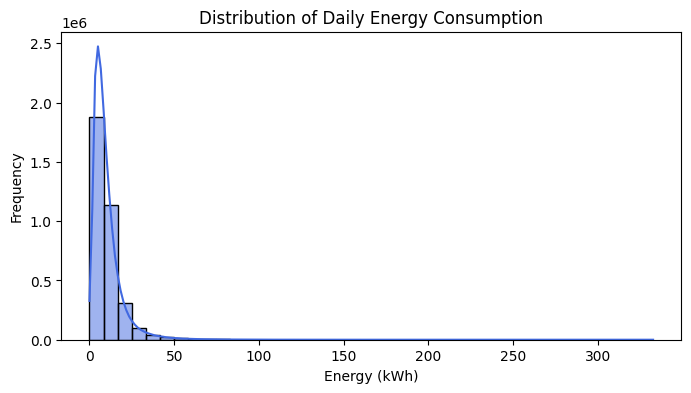

In [34]:
plt.figure(figsize=(8,4))
sns.histplot(merged_df['energy_sum'], kde=True, color='royalblue', bins=40)
plt.title("Distribution of Daily Energy Consumption")
plt.xlabel("Energy (kWh)")
plt.ylabel("Frequency")
plt.show()

In [35]:
# outliers
q1, q3 = merged_df['energy_sum'].quantile([0.25, 0.75])
iqr = q3 - q1
upper = q3 + 1.5 * iqr
outliers = merged_df[merged_df['energy_sum'] > upper]
print(f"Outliers detected: {len(outliers)} days ({len(outliers)/len(merged_df)*100:.2f}%)")

Outliers detected: 201571 days (5.74%)


##### Energy Consumption Over Time

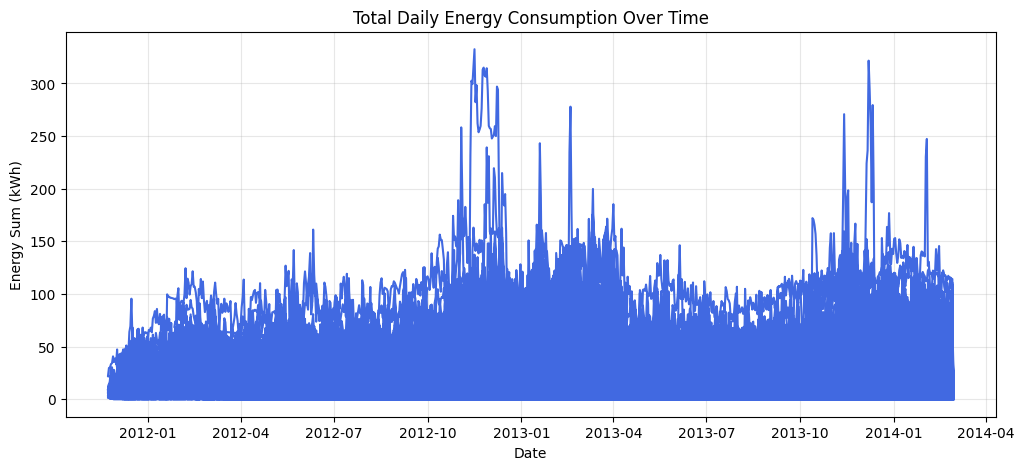

In [23]:
plt.figure(figsize=(12,5))
plt.plot(merged_df['day'], merged_df['energy_sum'], color='royalblue')
plt.title("Total Daily Energy Consumption Over Time")
plt.xlabel("Date")
plt.ylabel("Energy Sum (kWh)")
plt.grid(True, alpha=0.3)
plt.show()

##### Average Daily/Weekly Patterns

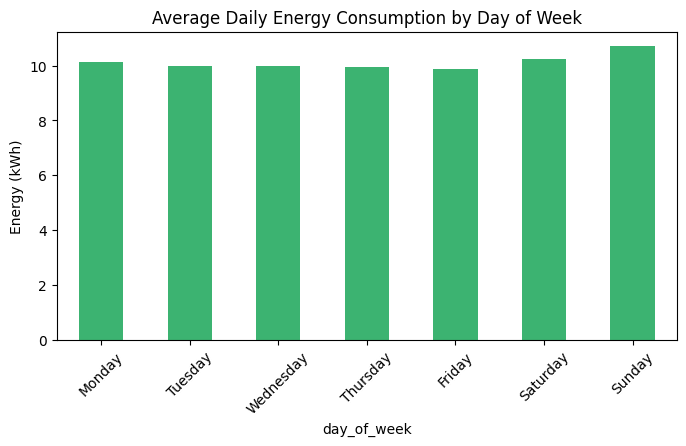

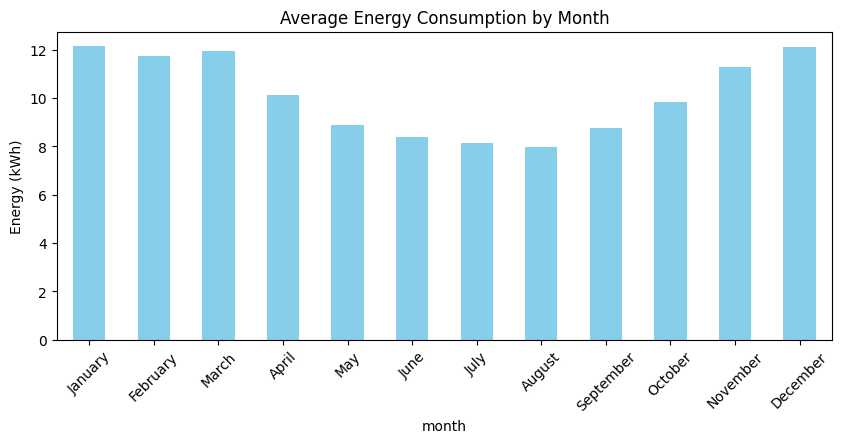

In [24]:
# Add day of week and month
merged_df['day_of_week'] = merged_df['day'].dt.day_name()
merged_df['month'] = merged_df['day'].dt.month_name()

# Average by day of week
plt.figure(figsize=(8,4))
merged_df.groupby('day_of_week')['energy_sum'].mean().reindex(
    ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
).plot(kind='bar', color='mediumseagreen')
plt.title("Average Daily Energy Consumption by Day of Week")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.show()

# Monthly trend
plt.figure(figsize=(10,4))
merged_df.groupby('month')['energy_sum'].mean().reindex(
    ['January','February','March','April','May','June','July','August','September','October','November','December']
).plot(kind='bar', color='skyblue')
plt.title("Average Energy Consumption by Month")
plt.ylabel("Energy (kWh)")
plt.xticks(rotation=45)
plt.show()


##### ACORN Group Insights

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1807978044.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='Acorn_grouped', y='energy_sum', palette='coolwarm')


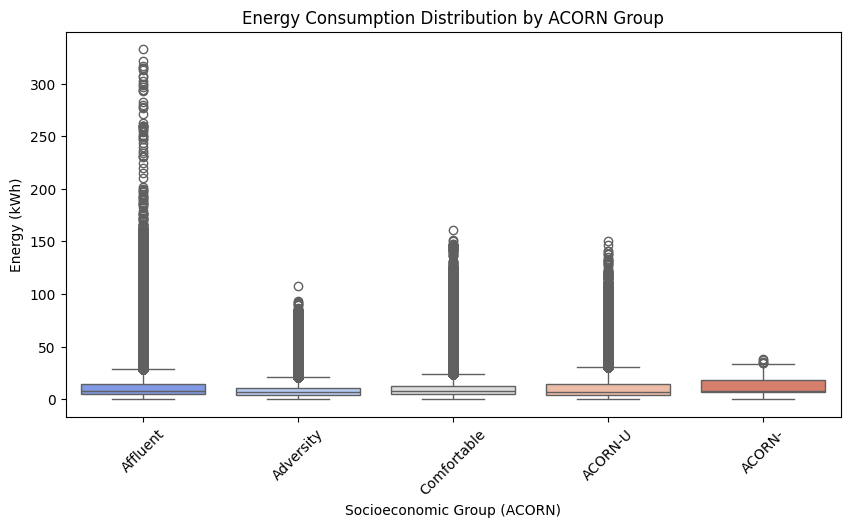

In [27]:
plt.figure(figsize=(10,5))
sns.boxplot(data=merged_df, x='Acorn_grouped', y='energy_sum', palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Energy Consumption Distribution by ACORN Group")
plt.ylabel("Energy (kWh)")
plt.xlabel("Socioeconomic Group (ACORN)")
plt.show()

In [28]:
# Mean consumption per group
acorn_avg = merged_df.groupby('Acorn_grouped')['energy_sum'].mean().sort_values(ascending=False)
print("\nAverage Energy by ACORN Group:\n", acorn_avg)


Average Energy by ACORN Group:
 Acorn_grouped
ACORN-         12.003773
ACORN-U        11.617296
Affluent       11.478613
Comfortable    10.004460
Adversity       8.503382
Name: energy_sum, dtype: float64


##### Weather Relationship

In [29]:
numeric_weather_cols = ['temperatureMax', 'temperatureMin', 'windSpeed', 'humidity', 'pressure', 'cloudCover']
corrs = merged_df[numeric_weather_cols + ['energy_sum']].corr()['energy_sum'].sort_values(ascending=False)

print("\nCorrelation with Energy Consumption:\n", corrs)


Correlation with Energy Consumption:
 energy_sum        1.000000
pressure          0.004800
windSpeed         0.000300
temperatureMax   -0.000354
humidity         -0.015374
temperatureMin   -0.027143
cloudCover       -0.029703
Name: energy_sum, dtype: float64


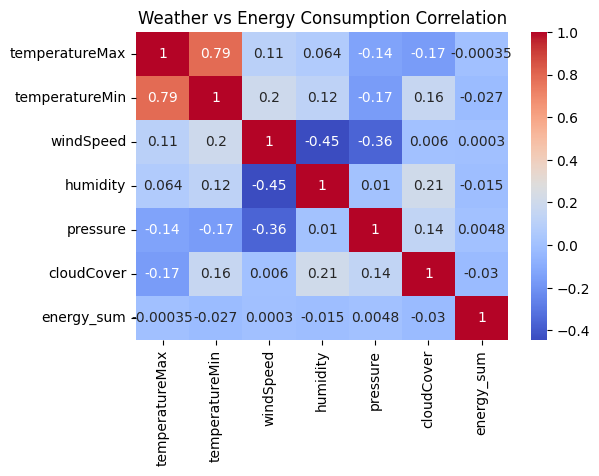

In [30]:
plt.figure(figsize=(6,4))
sns.heatmap(merged_df[numeric_weather_cols + ['energy_sum']].corr(), annot=True, cmap='coolwarm')
plt.title("Weather vs Energy Consumption Correlation")
plt.show()

##### Holidays Impact

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1787650211.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='is_holiday', y='energy_sum', data=merged_df, palette='Set2')


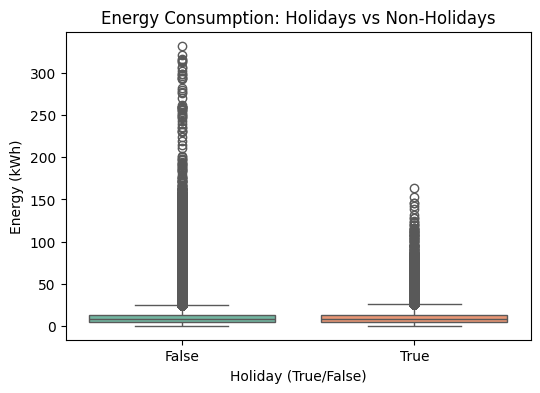

In [31]:
plt.figure(figsize=(6,4))
sns.boxplot(x='is_holiday', y='energy_sum', data=merged_df, palette='Set2')
plt.title("Energy Consumption: Holidays vs Non-Holidays")
plt.xlabel("Holiday (True/False)")
plt.ylabel("Energy (kWh)")
plt.show()

In [32]:
holiday_avg = merged_df.groupby('is_holiday')['energy_sum'].mean()
print("\nAverage Energy Consumption:\n", holiday_avg)


Average Energy Consumption:
 is_holiday
False    10.117362
True     10.412623
Name: energy_sum, dtype: float64


##### Time Trend

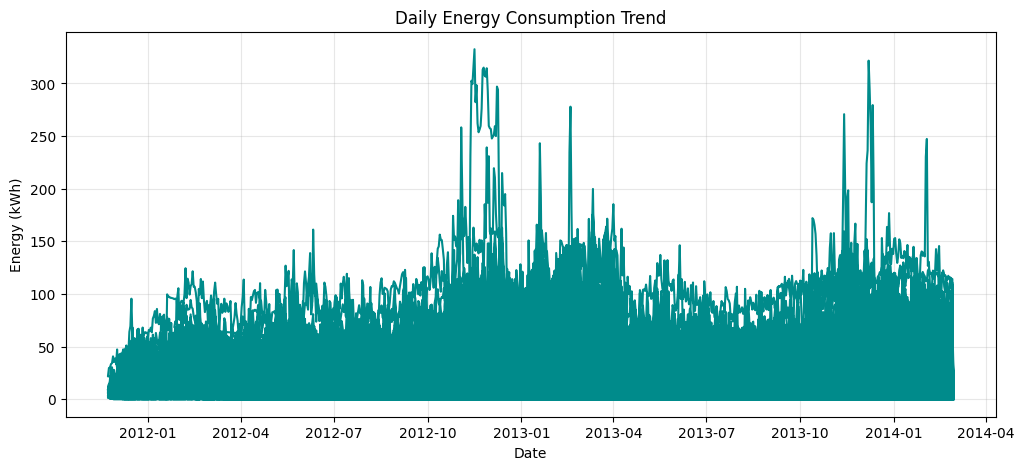

In [36]:
plt.figure(figsize=(12,5))
plt.plot(merged_df['day'], merged_df['energy_sum'], color='darkcyan')
plt.title("Daily Energy Consumption Trend")
plt.xlabel("Date")
plt.ylabel("Energy (kWh)")
plt.grid(alpha=0.3)
plt.show()

##### Rolling Mean for Trend Smoothing

C:\Users\LOQ\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


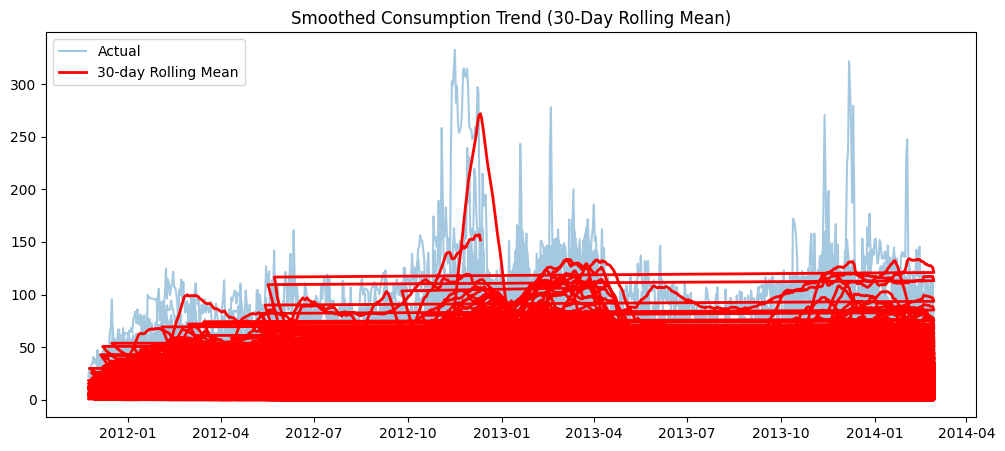

In [37]:
merged_df['rolling_mean'] = merged_df['energy_sum'].rolling(window=30).mean()

plt.figure(figsize=(12,5))
plt.plot(merged_df['day'], merged_df['energy_sum'], alpha=0.4, label='Actual')
plt.plot(merged_df['day'], merged_df['rolling_mean'], color='red', linewidth=2, label='30-day Rolling Mean')
plt.legend()
plt.title("Smoothed Consumption Trend (30-Day Rolling Mean)")
plt.show()

##### Seasonality, Day-of-Week & Month Patterns

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1983855824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='day_of_week', y='energy_sum',


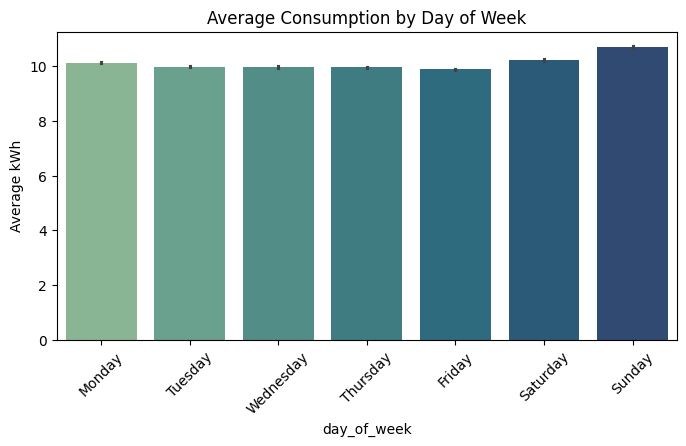

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1983855824.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=merged_df, x='month', y='energy_sum',


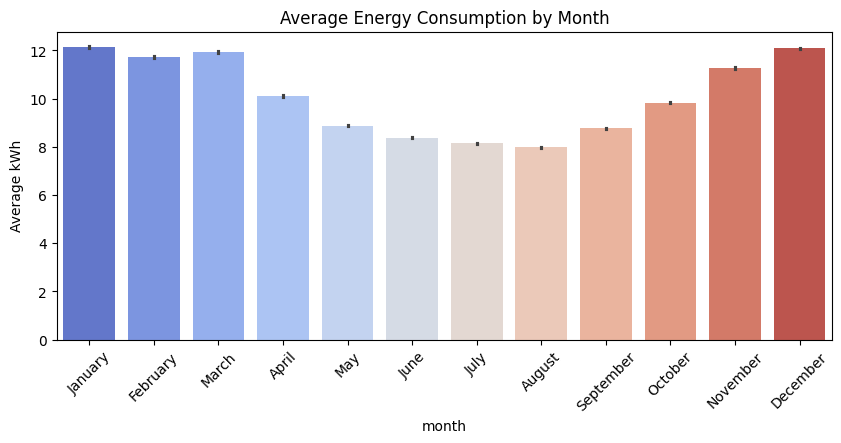

In [38]:
merged_df['month'] = merged_df['day'].dt.month_name()
merged_df['day_of_week'] = merged_df['day'].dt.day_name()

# Average by day of week
plt.figure(figsize=(8,4))
sns.barplot(data=merged_df, x='day_of_week', y='energy_sum', 
            order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'],
            palette='crest')
plt.xticks(rotation=45)
plt.title("Average Consumption by Day of Week")
plt.ylabel("Average kWh")
plt.show()

# Average by month
plt.figure(figsize=(10,4))
sns.barplot(data=merged_df, x='month', y='energy_sum',
            order=['January','February','March','April','May','June','July','August','September','October','November','December'],
            palette='coolwarm')
plt.xticks(rotation=45)
plt.title("Average Energy Consumption by Month")
plt.ylabel("Average kWh")
plt.show()

##### Weather–Energy Relationship

Correlation with Energy Consumption:
 energy_sum        1.000000
pressure          0.004800
windSpeed         0.000300
temperatureMax   -0.000354
humidity         -0.015374
temperatureMin   -0.027143
cloudCover       -0.029703
Name: energy_sum, dtype: float64


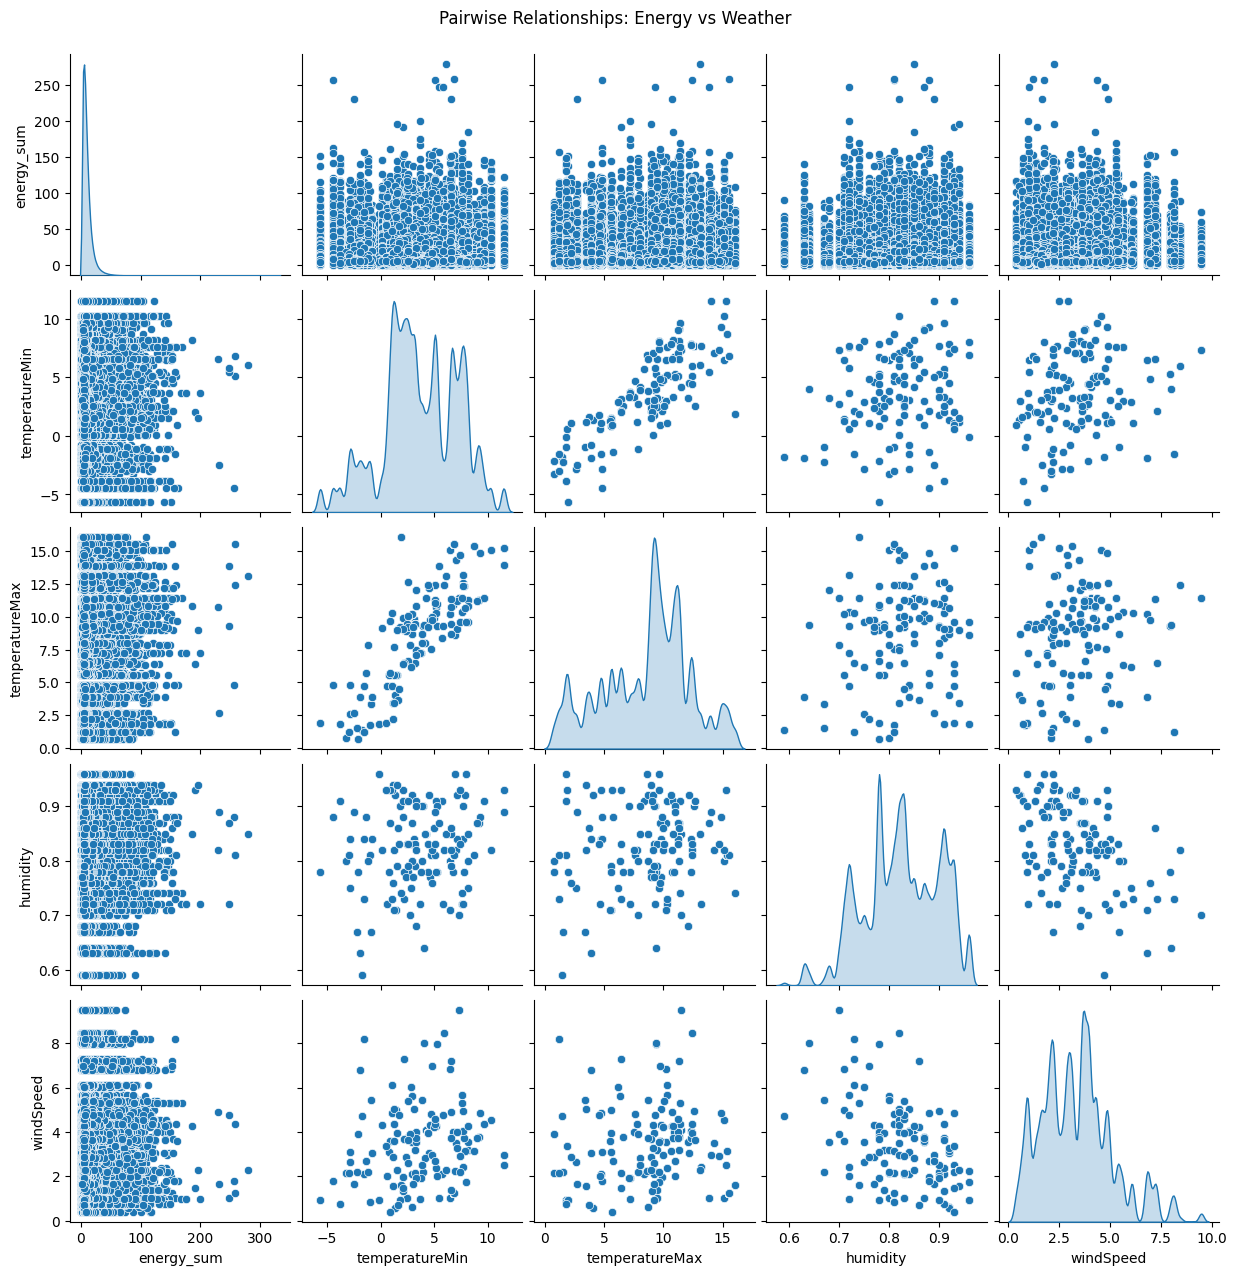

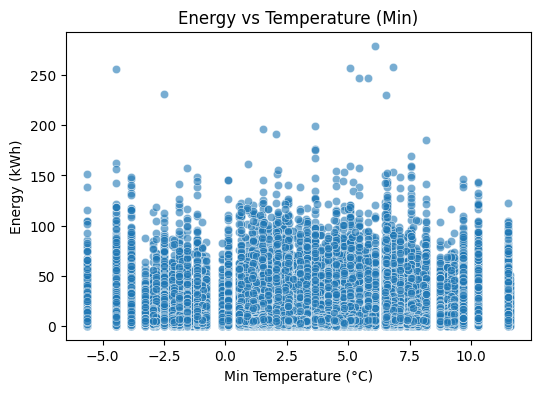

In [40]:
# Select relevant weather columns
weather_cols = ['temperatureMin', 'temperatureMax', 'humidity', 'windSpeed', 'pressure', 'cloudCover']
corrs = merged_df[weather_cols + ['energy_sum']].corr()['energy_sum'].sort_values(ascending=False)
print("Correlation with Energy Consumption:\n", corrs)

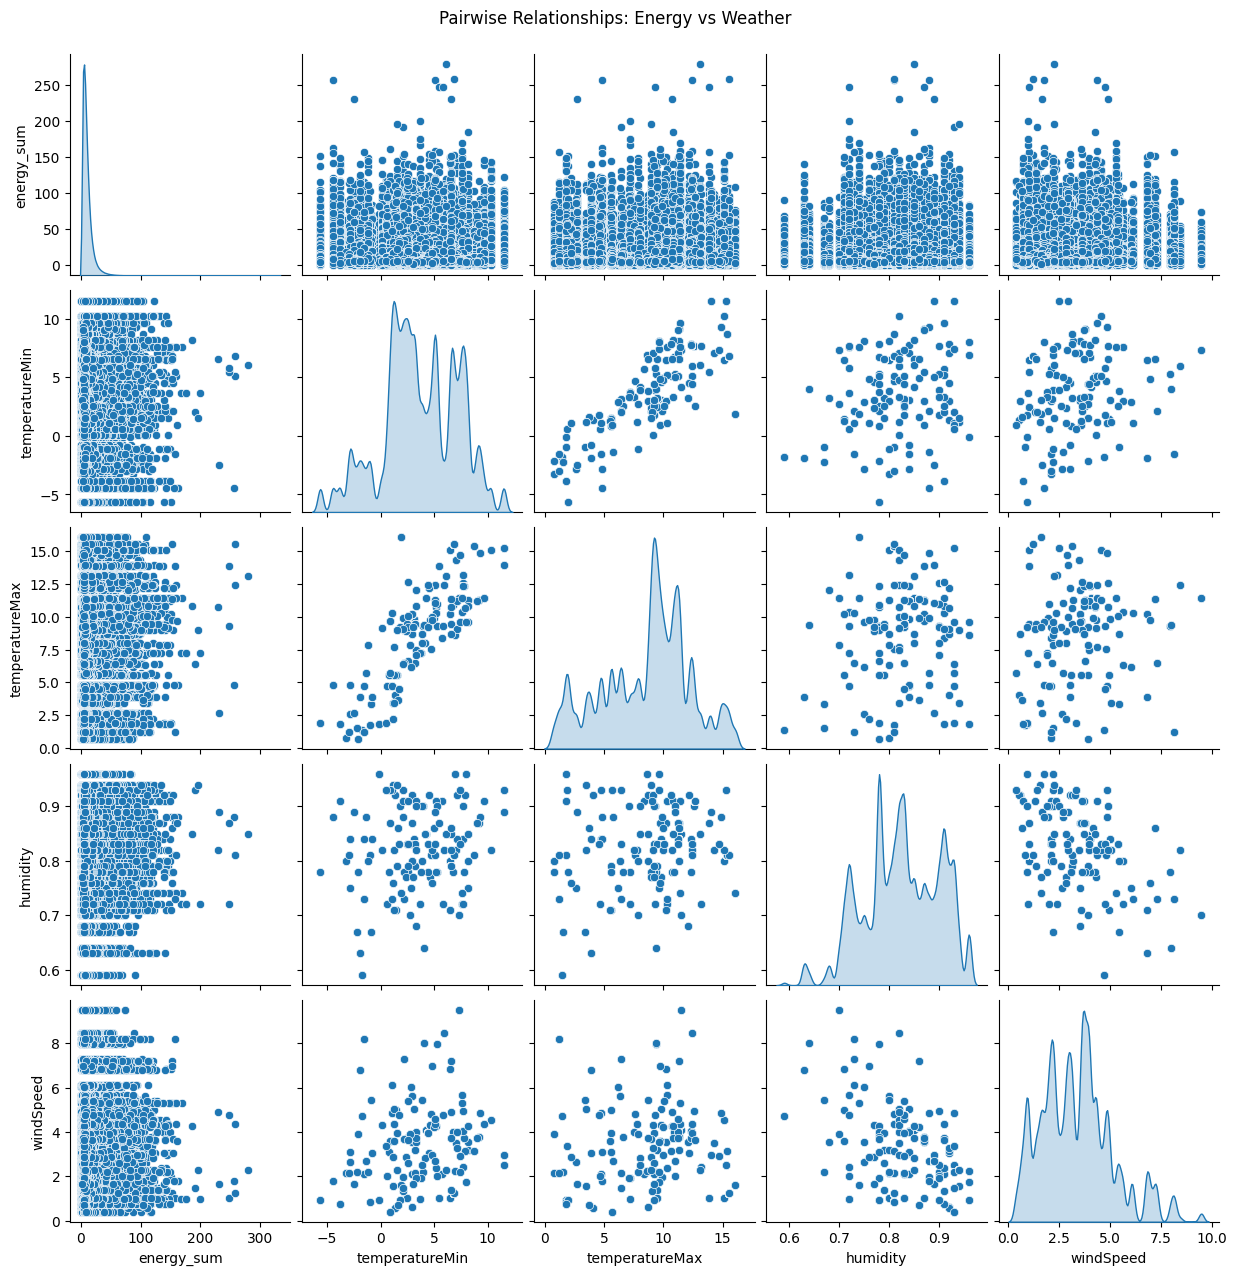

In [48]:
# Pairplot for key variables
sns.pairplot(merged_df[['energy_sum', 'temperatureMin', 'temperatureMax', 'humidity', 'windSpeed']], diag_kind='kde')
plt.suptitle("Pairwise Relationships: Energy vs Weather", y=1.02)
plt.show()

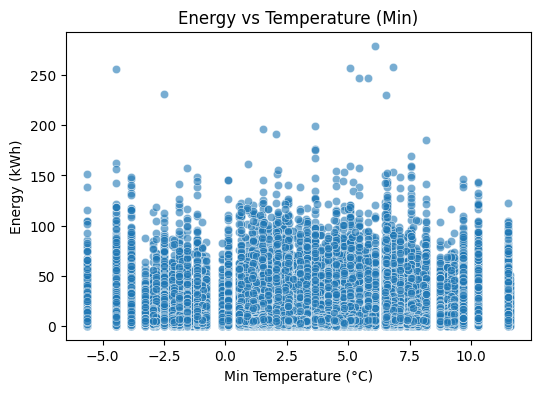

In [49]:
# Scatterplot example: temperature vs energy
plt.figure(figsize=(6,4))
sns.scatterplot(x='temperatureMin', y='energy_sum', data=merged_df, alpha=0.6)
plt.title("Energy vs Temperature (Min)")
plt.xlabel("Min Temperature (°C)")
plt.ylabel("Energy (kWh)")
plt.show()

##### Socioeconomic (ACORN) Consumption Insights

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1679030690.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='Acorn_grouped', y='energy_sum', palette='viridis')


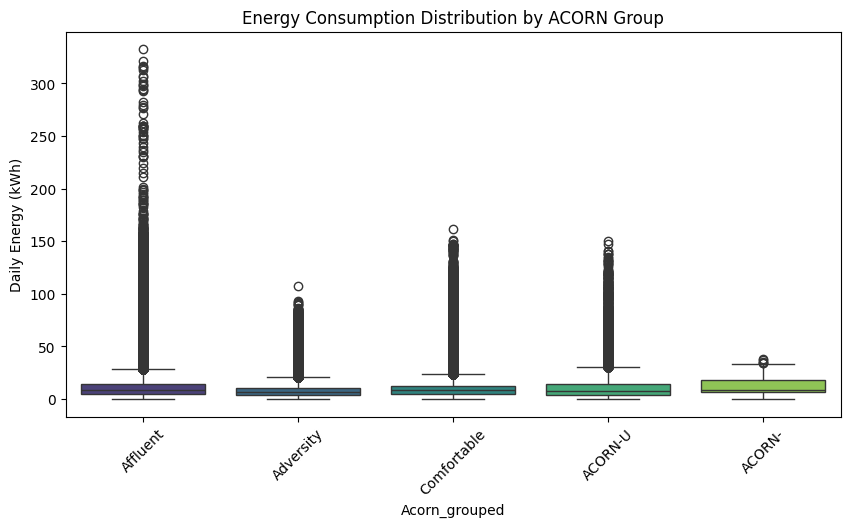

In [41]:
plt.figure(figsize=(10,5))
sns.boxplot(data=merged_df, x='Acorn_grouped', y='energy_sum', palette='viridis')
plt.xticks(rotation=45)
plt.title("Energy Consumption Distribution by ACORN Group")
plt.ylabel("Daily Energy (kWh)")
plt.show()

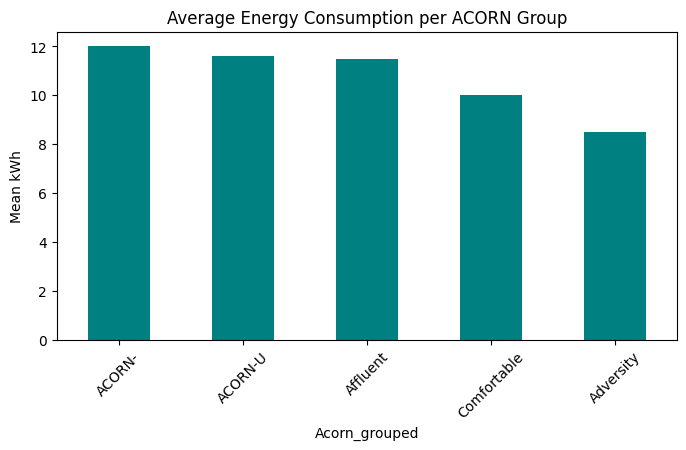

In [42]:
# Mean consumption per ACORN group
acorn_means = merged_df.groupby('Acorn_grouped')['energy_sum'].mean().sort_values(ascending=False)
acorn_means.plot(kind='bar', color='teal', figsize=(8,4))
plt.title("Average Energy Consumption per ACORN Group")
plt.ylabel("Mean kWh")
plt.xticks(rotation=45)
plt.show()

In [43]:
print(acorn_means)

Acorn_grouped
ACORN-         12.003773
ACORN-U        11.617296
Affluent       11.478613
Comfortable    10.004460
Adversity       8.503382
Name: energy_sum, dtype: float64


##### Holidays vs Non-Holidays

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\1329319313.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_df, x='is_holiday', y='energy_sum', palette='Set2')


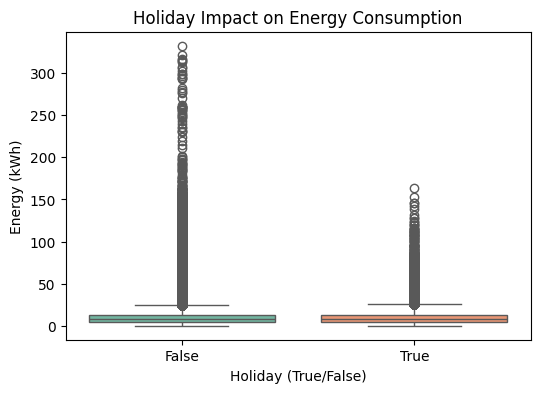

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(data=merged_df, x='is_holiday', y='energy_sum', palette='Set2')
plt.title("Holiday Impact on Energy Consumption")
plt.xlabel("Holiday (True/False)")
plt.ylabel("Energy (kWh)")
plt.show()

In [45]:
holiday_stats = merged_df.groupby('is_holiday')['energy_sum'].agg(['mean','std','count'])
print("\nHoliday vs Non-Holiday Summary:\n", holiday_stats)


Holiday vs Non-Holiday Summary:
                  mean       std    count
is_holiday                              
False       10.117362  9.115387  3429773
True        10.412623  9.677560    80630


##### Energy vs Temperature Interactive Curve

C:\Users\LOQ\AppData\Local\Temp\ipykernel_18824\859148487.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  energy_by_temp = merged_df.groupby(temp_bins)['energy_sum'].mean()


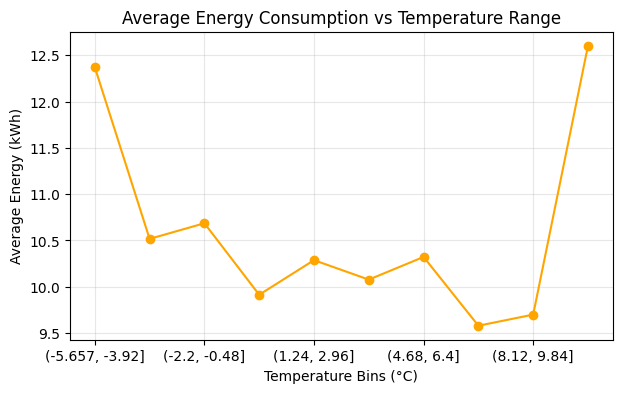

In [47]:
# Bin temperature and compute mean energy
temp_bins = pd.cut(merged_df['temperatureMin'], bins=10)
energy_by_temp = merged_df.groupby(temp_bins)['energy_sum'].mean()

plt.figure(figsize=(7,4))
energy_by_temp.plot(kind='line', marker='o', color='orange')
plt.title("Average Energy Consumption vs Temperature Range")
plt.xlabel("Temperature Bins (°C)")
plt.ylabel("Average Energy (kWh)")
plt.grid(True, alpha=0.3)
plt.show()

##### Correlation Heatmap (Overall Features)

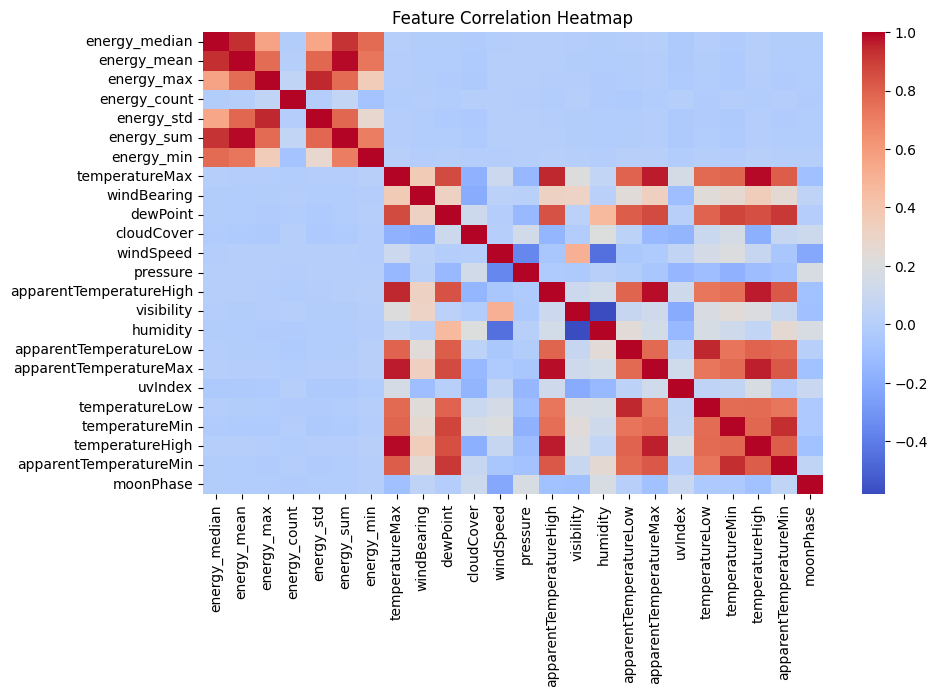

In [33]:
plt.figure(figsize=(10,6))
sns.heatmap(merged_df.select_dtypes('number').corr(), cmap='coolwarm', annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()


##### Correlation Matrix & Feature Understanding

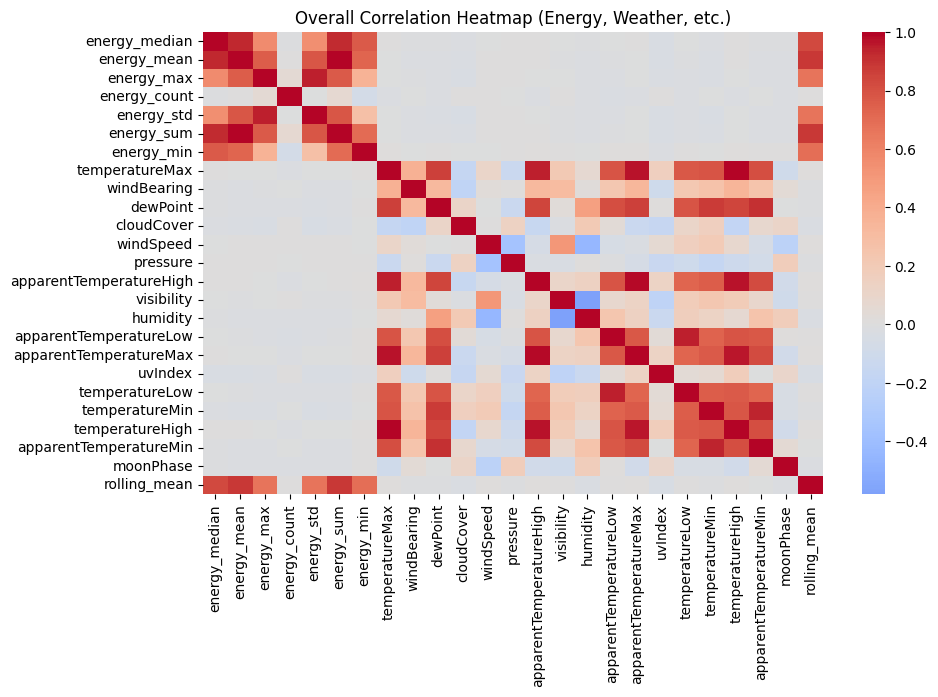

In [46]:
plt.figure(figsize=(10,6))
sns.heatmap(merged_df.select_dtypes('number').corr(), cmap='coolwarm', center=0)
plt.title("Overall Correlation Heatmap (Energy, Weather, etc.)")
plt.show()
